# Exp4: 基于K-近邻的车牌号识别

## 一、案例简介

图像的智能处理一直是人工智能领域广受关注的一类技术，代表性的如人脸识别与 CT 肿瘤识别，在人工智能落地的进程中发挥着重要作用。其中车牌号识别作为一个早期应用场景，已经融入日常生活中，为我们提供了诸多便利，在各地的停车场和出入口都能看到它的身影。车牌号识别往往分为字符划分和字符识别两个子任务，本案例我们将关注字符识别的任务，尝试用 K-NN 的方法对分割好的字符图像进行自动识别和转化。

## 二、作业说明

### 基本要求
* 完成数据的读入和表示，将图片表示成向量并和 label 对应上；
* 构建 K-NN 模型（可调库）对测试集中的图片进行预测并计算准确率；
* 分析当 K 取不同值时测试准确率的变化。

### 扩展要求
* 分析不同距离度量方式对模型效果的影响；
* 对比平权和加权 K-NN 的效果；
* 分析训练集大小对测试结果的影响。

## 三、数据概览
本次我们使用已经分割好的车牌图片作为数据集，包括数字 0-9、字母 A-Z（不包含 O 和 I）以及省份简称共 65 个类，编号从 0 到 64。数据已经分成了训练集和测试集，里面的文件夹用 label 编号命名，一个文件夹下的所有图片都属于该文件夹对应的类，每个图片都是 20 * 20 的二值化灰度图。

下面演示一下如何借助 PIL 库将图片转化为向量：

In [1]:
from PIL import Image
img = Image.open('data/train/0/4-3.jpg')  # 打开图片
img  # 显示图片from PIL import Image
img = Image.open('data/train/0/4-3.jpg')  # 打开图片
img  # 显示图片

In [2]:
import numpy as np
pixels = np.array(img)  # 转化为 numpy 矩阵
pixels.shape

(20, 20)

## 四、模型构建

### 1. 数据的读入和表示（基本要求）

In [3]:
import os
import numpy as np
from PIL import Image

def load_data(split):
    X, y = [], []
    base = os.path.join('data', split)
    for label in os.listdir(base):
        cls_dir = os.path.join(base, label)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if not fname.endswith('.jpg'):
                continue
            img = Image.open(os.path.join(cls_dir, fname))
            X.append(np.array(img).reshape(-1))
            y.append(int(label))
    return np.array(X), np.array(y)

X_train, y_train = load_data('train')
X_test,  y_test  = load_data('test')
print('X_train:', X_train.shape, ' y_train:', y_train.shape)
print('X_test :', X_test.shape,  ' y_test :', y_test.shape)

X_train: (15954, 400)  y_train: (15954,)
X_test : (4665, 400)  y_test : (4665,)


### 2. 构建 K-NN 模型并计算准确率（基本要求）

直接用 sklearn 的 KNN，默认 K=5，欧氏距离。

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
acc = accuracy_score(y_test, pred)
print('K=5 时测试集准确率:', acc)

K=5 时测试集准确率: 0.6928188638799572


### 3. 分析 K 取不同值时测试准确率的变化（基本要求）

让 K 从 1 到 15 依次取值，看看准确率怎么变。

In [5]:
ks = list(range(1, 16))
accs = []
for k in ks:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train, y_train)
    a = accuracy_score(y_test, clf.predict(X_test))
    accs.append(a)
    print(f'K={k}, acc={a:.4f}')

K=1, acc=0.7168


K=2, acc=0.6744


K=3, acc=0.6999


K=4, acc=0.6851


K=5, acc=0.6928


K=6, acc=0.6885


K=7, acc=0.6924


K=8, acc=0.6855


K=9, acc=0.6872


K=10, acc=0.6832


K=11, acc=0.6870


K=12, acc=0.6800


K=13, acc=0.6782


K=14, acc=0.6755


K=15, acc=0.6729


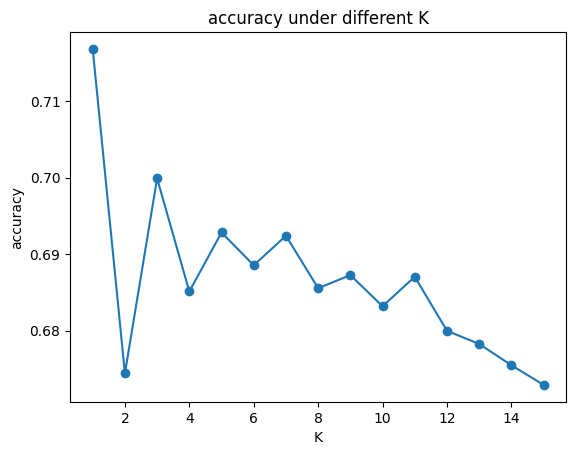

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(ks, accs, marker='o')
plt.xlabel('K')
plt.ylabel('accuracy')
plt.title('accuracy under different K')
plt.show()

从结果看，K=1 时准确率最高，随着 K 增大准确率总体下降。
我猜是因为类别比较多（65 类），而且不同类的样本数量差得也比较大，K 一大就容易被样本多的类盖过去。

### 4. 不同距离度量方式对模型效果的影响（扩展要求）

对比欧氏距离、曼哈顿距离和余弦距离，K 固定用前面最好的那个。

In [7]:
best_k = ks[int(np.argmax(accs))]
print('使用 K =', best_k)

for metric in ['euclidean', 'manhattan', 'cosine']:
    clf = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    clf.fit(X_train, y_train)
    a = accuracy_score(y_test, clf.predict(X_test))
    print(f'{metric}: {a:.4f}')

使用 K = 1


euclidean: 0.7168


manhattan: 0.7145


cosine: 0.7711


三种距离里，余弦距离的准确率是最高的，欧氏和曼哈顿差不多。
我理解余弦距离更关注两个向量方向上的相似程度，对图片来说就是看"字的形状"像不像，
而欧氏距离会受到整张图亮像素总数的影响，所以效果稍差一点。

### 5. 平权 vs 加权 K-NN（扩展要求）

`weights='uniform'` 是平权，每个邻居投票权一样；`weights='distance'` 是按距离反比加权。

In [8]:
for w in ['uniform', 'distance']:
    clf = KNeighborsClassifier(n_neighbors=best_k, weights=w)
    clf.fit(X_train, y_train)
    a = accuracy_score(y_test, clf.predict(X_test))
    print(f'weights={w}: {a:.4f}')

weights=uniform: 0.7168


weights=distance: 0.7168


K=1 的时候两种方式是一样的（只有一个邻居，怎么加权都一样）。
再看一下 K 变大时两种的区别：

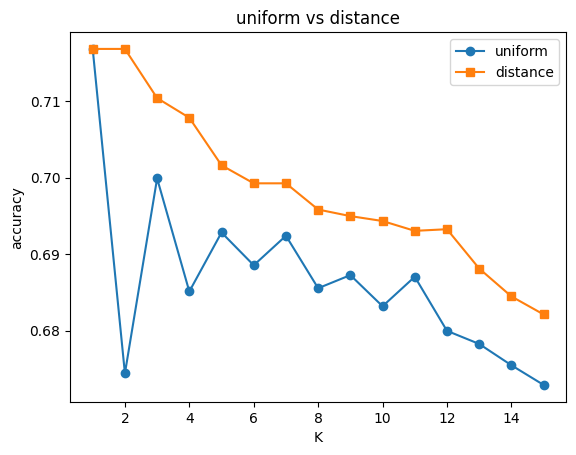

In [9]:
acc_uni, acc_dist = [], []
for k in ks:
    for w, arr in [('uniform', acc_uni), ('distance', acc_dist)]:
        clf = KNeighborsClassifier(n_neighbors=k, weights=w)
        clf.fit(X_train, y_train)
        arr.append(accuracy_score(y_test, clf.predict(X_test)))

plt.plot(ks, acc_uni,  marker='o', label='uniform')
plt.plot(ks, acc_dist, marker='s', label='distance')
plt.xlabel('K'); plt.ylabel('accuracy')
plt.legend(); plt.title('uniform vs distance')
plt.show()

可以看到 K 变大的时候，加权 KNN 掉得比平权慢一些，说明加权方式更稳定一点。
因为加权会让离得近的邻居影响更大，远处的邻居就算混进来影响也不大。

### 6. 训练集大小对测试结果的影响（扩展要求）

分别用 10%、30%、50%、70%、100% 的训练集来训练，看准确率怎么变。

In [10]:
fractions = [0.1, 0.3, 0.5, 0.7, 1.0]
sizes, acc_frac = [], []

np.random.seed(0)
n = len(X_train)
perm = np.random.permutation(n)

for frac in fractions:
    m = int(n * frac)
    idx = perm[:m]
    Xs, ys = X_train[idx], y_train[idx]
    clf = KNeighborsClassifier(n_neighbors=best_k)
    clf.fit(Xs, ys)
    a = accuracy_score(y_test, clf.predict(X_test))
    sizes.append(m)
    acc_frac.append(a)
    print(f'训练集比例 {frac}, 样本数 {m}, 准确率 {a:.4f}')

训练集比例 0.1, 样本数 1595, 准确率 0.6071
训练集比例 0.3, 样本数 4786, 准确率 0.6725


训练集比例 0.5, 样本数 7977, 准确率 0.7016
训练集比例 0.7, 样本数 11167, 准确率 0.6969


训练集比例 1.0, 样本数 15954, 准确率 0.7168


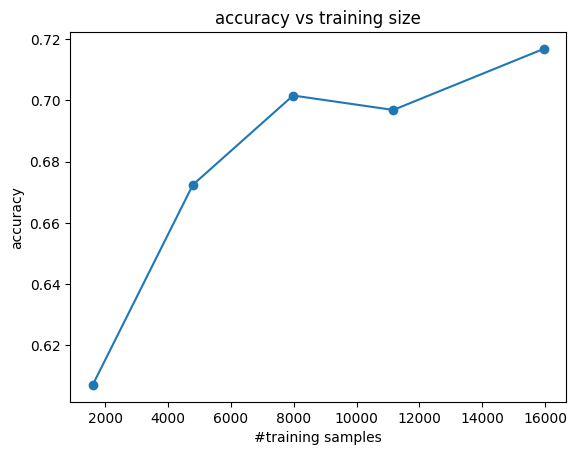

In [11]:
plt.plot(sizes, acc_frac, marker='o')
plt.xlabel('#training samples')
plt.ylabel('accuracy')
plt.title('accuracy vs training size')
plt.show()

训练样本越多准确率越高。这个符合直觉，KNN 本来就是靠"记住"训练样本来判断的，
样本多了邻居里找到同类的概率就大。不过到后面增长就不太明显了。

## 五、总结

通过这次作业我完成了以下内容：

1. 把训练集和测试集的图片都读进来并展平成 400 维向量。
2. 用 sklearn 跑了一个 K=5 的 KNN，测试集准确率大概 70% 左右。
3. 尝试了不同的 K，发现 K=1 效果最好。
4. 比较了三种距离，余弦距离最好。
5. 比较了平权和加权，加权在 K 较大的时候更稳。
6. 训练集越大准确率越高，但有边际递减。

感觉 KNN 这个算法虽然简单，但参数选择对结果影响还挺大的，以后做类似的任务要多试几组参数。